# Condition Informativeness Analysis

Tests three core questions about learned conditions:

| Section | Question | Method |
|---|---|---|
| 1 | Are conditions **type-discriminative**? | Condition-space clustering + effect consistency test |
| 2 | Do condition types **match query types**? | Condition × query-type R@1 matrix |
| 3 | Do conditions carry **real information** (vs random)? | Permutation null-distribution tests |
| 4 | **Predictor** specificity and quality | PCA + type-affinity + per-image analysis |
| 5 | **Aggregation** strategies comparison | 7 strategies, all query types |
| 6 | Automatic statistical summary | Rule-based conclusions from all tests |

The oracle (best representative per query) is always shown as an **upper bound only** — not as a deployable strategy.

In [1]:
EXPERIMENT_DIR = (
    "/project/CoSiR/res/CoSiR_Experiment/impressions/20260602_054458_sweep_73jsta4o"
)
EPOCH      = None
DEVICE     = "cuda"
TYPE_NAMES  = ["caption", "description", "impression", "aesthetic"]
TYPE_COLORS = ["#888888", "#2196F3", "#FF9800", "#4CAF50"]
N_BOOT     = 500   # permutation-test iterations
N_PROBE    = 50    # probe images for effect-consistency test
N_PER_TYPE = 15    # conditions sampled per type for consistency test

In [2]:
import os, glob, warnings
from itertools import combinations
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu, binomtest, norm
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
warnings.filterwarnings("ignore")

import importlib.util as _ilu
def _load_file(name, path):
    spec = _ilu.spec_from_file_location(name, path)
    mod  = _ilu.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

_proj = os.path.normpath(os.path.join(os.path.abspath(""), "../../.."))
_cm   = _load_file("combiner", os.path.join(_proj, "src/model/combiner.py"))
Combiner_new       = _cm.Combiner_new
OtherProjMLP       = _cm.OtherProjMLP
ConditionPredictor = _load_file(
    "condition_predictor",
    os.path.join(_proj, "src/model/condition_predictor.py")
).ConditionPredictor
print("Modules loaded")


Modules loaded


In [3]:
cond_dir = os.path.join(EXPERIMENT_DIR, "condition_viz")
ca_dir   = os.path.join(EXPERIMENT_DIR, "condition_analysis")

fixed = torch.load(os.path.join(cond_dir, "fixed_data.pt"), map_location="cpu", weights_only=False)
all_img_emb    = fixed["all_img_emb"]
all_txt_emb    = fixed["all_txt_emb"]
img2txt        = fixed["image_to_text_map"]
txt2img        = fixed["text_to_image_map"]
cpi            = fixed["captions_per_image"]
test_cap_types = fixed["test_caption_types"]
n_img, n_txt   = all_img_emb.shape[0], all_txt_emb.shape[0]
print(f"Test: {n_img} images × {cpi} caps = {n_txt} texts")

epoch_files = sorted(glob.glob(os.path.join(cond_dir, "epoch_*.pt")))
snap        = torch.load(epoch_files[-1] if EPOCH is None else
                         os.path.join(cond_dir, f"epoch_{EPOCH:04d}.pt"),
                         map_location="cpu", weights_only=False)
epoch          = snap["epoch"]
label_emb_all  = snap["label_embeddings_all"]   # [N_train, D_cond]
representatives = snap["representatives"]         # [K, D_cond]
combine_side    = snap.get("combine_side", "img")
train_types     = snap.get("train_sample_types")
K, label_dim    = len(representatives), representatives.shape[1]
print(f"Epoch {epoch} | K={K} | label_dim={label_dim} | combine_side={combine_side}")
if train_types is not None:
    print("Train type counts:", {TYPE_NAMES[t]: (train_types==t).sum().item() for t in range(4)})

HAS_CA = False
ca_files = sorted(glob.glob(os.path.join(ca_dir, "epoch_*.pt"))) if os.path.exists(ca_dir) else []
if ca_files:
    ca = torch.load(ca_files[-1], map_location="cpu", weights_only=False)
    per_rep_gt_rank = ca["per_rep_gt_rank"]   # [K, N_txt]
    HAS_CA = True
    print(f"CA cache loaded")

dev = torch.device(DEVICE if torch.cuda.is_available() else "cpu")
cfg = snap["combiner_config"]
combiner = Combiner_new(
    clip_feature_dim=cfg["clip_feature_dim"],
    projection_dim=cfg["projection_dim"],
    label_dim=cfg["label_dim"],
    hidden_dim=cfg.get("hidden_dim", cfg["clip_feature_dim"]),
    num_heads=cfg.get("num_heads", 8),
    num_layers=cfg.get("num_layers", 2),
    dropout=cfg.get("dropout", 0.1),
).to(dev).eval()
combiner.load_state_dict(snap["combiner_state_dict"])

_fd     = cfg["clip_feature_dim"]
_op_cfg = snap.get("other_proj_config", {})
if _op_cfg.get("type") == "OtherProjMLP":
    other_proj = OtherProjMLP(feature_dim=_fd,
                              hidden_dim=_op_cfg.get("hidden_dim", 1024),
                              num_blocks=_op_cfg.get("num_blocks", 3))
else:
    other_proj = torch.nn.Linear(_fd, _fd)
    torch.nn.init.eye_(other_proj.weight); torch.nn.init.zeros_(other_proj.bias)
if "other_proj_state_dict" in snap:
    other_proj.load_state_dict(snap["other_proj_state_dict"])
other_proj = other_proj.to(dev).eval()

predictor = None
if "predictor_state_dict" in snap:
    pcfg = snap["predictor_config"]
    predictor = ConditionPredictor(
        input_dim=pcfg["input_dim"], hidden_dim=pcfg["hidden_dim"],
        output_dim=pcfg["output_dim"], num_layers=pcfg.get("num_layers",2),
        dropout=pcfg.get("dropout",0.1),
    ).to(dev).eval()
    predictor.load_state_dict(snap["predictor_state_dict"])
    print("Predictor loaded")

img_n = F.normalize(all_img_emb, dim=-1)
txt_n = F.normalize(all_txt_emb, dim=-1)
with torch.no_grad():
    other_n = F.normalize(other_proj(
        (all_img_emb if combine_side=="txt" else all_txt_emb).to(dev)), dim=-1).cpu()
print("Models ready")

Test: 706 images × 4 caps = 2824 texts
Epoch 999 | K=30 | label_dim=16 | combine_side=img
Train type counts: {'caption': 1423, 'description': 3565, 'impression': 3566, 'aesthetic': 3569}
CA cache loaded
Predictor loaded
Models ready


In [4]:
combine_emb = all_img_emb if combine_side == "img" else all_txt_emb

@torch.no_grad()
def apply_cond(emb, cond, bs=256):
    out = []
    for i in range(0, emb.shape[0], bs):
        e = emb[i:i+bs].to(dev)
        out.append(combiner(e, None, cond.expand(e.shape[0],-1).to(dev)).cpu())
    return F.normalize(torch.cat(out), dim=-1)

def r_at_k(ranks, k):
    return (ranks < k).float().mean().item() * 100

def t2i_ranks_from_sims(sims):
    """sims: [N_txt, N_img] → ranks [N_txt]"""
    gt_s = sims[torch.arange(n_txt), txt2img]
    return (sims >= gt_s.unsqueeze(1)).sum(1).long() - 1

def t2i_ranks_subset(sims, txt_idx):
    """sims: [N_txt, N_img] — evaluate only txt_idx queries"""
    s    = sims[txt_idx]
    gt_s = s[torch.arange(len(txt_idx)), txt2img[txt_idx]]
    return (s >= gt_s.unsqueeze(1)).sum(1).long() - 1

def comb_t2i(out_n):
    return (other_n @ out_n.T) if combine_side=="img" else (out_n @ other_n.T)

# ── Type-mean conditions ──────────────────────────────────────────────────────
assert train_types is not None, "train_types required"
type_means   = torch.stack([label_emb_all[train_types==t].mean(0) for t in range(4)])
cond_avg_all = type_means.mean(0, keepdim=True)

# Combiner outputs for each type-mean condition: [4, N_img, 512]
print("Computing type-specific combiner outputs...")
type_cond_out = torch.stack([apply_cond(combine_emb, type_means[t:t+1]) for t in range(4)])

# Zero and avg-cond outputs
out_zero = apply_cond(combine_emb, torch.zeros(1, label_dim))
out_avg  = apply_cond(combine_emb, cond_avg_all)

# Predicted condition
raw_pred   = None
out_pred_n = None
if predictor is not None:
    src = all_img_emb if combine_side=="img" else all_txt_emb
    with torch.no_grad():
        raw_pred = torch.cat([predictor(src[i:i+512].to(dev)).cpu()
                              for i in range(0, src.shape[0], 512)])
    with torch.no_grad():
        pred_out = torch.cat([
            combiner(combine_emb[i:i+256].to(dev), None, raw_pred[i:i+256].to(dev)).cpu()
            for i in range(0, combine_emb.shape[0], 256)])
    out_pred_n = F.normalize(pred_out, dim=-1)
    print(f"Predicted conditions: {raw_pred.shape}")

# Per-rep combiner outputs: [K, N_combine, 512]
print("Computing per-rep outputs...")
per_rep_comb_out = torch.stack([
    apply_cond(combine_emb, representatives[k:k+1]) for k in range(K)
])

# CLIP baseline sims
sims_clip = txt_n @ img_n.T
print("All precomputed.")

Computing type-specific combiner outputs...
Predicted conditions: torch.Size([706, 16])
Computing per-rep outputs...
All precomputed.


---
## 1 — Q1: Are Conditions Type-Discriminative?

Two complementary views:  
**1A** — *Condition space*: are the 16-dim condition vectors separable by type?  
**1B** — *Effect consistency*: when applied to the same images, do same-type conditions produce similar combiner outputs?

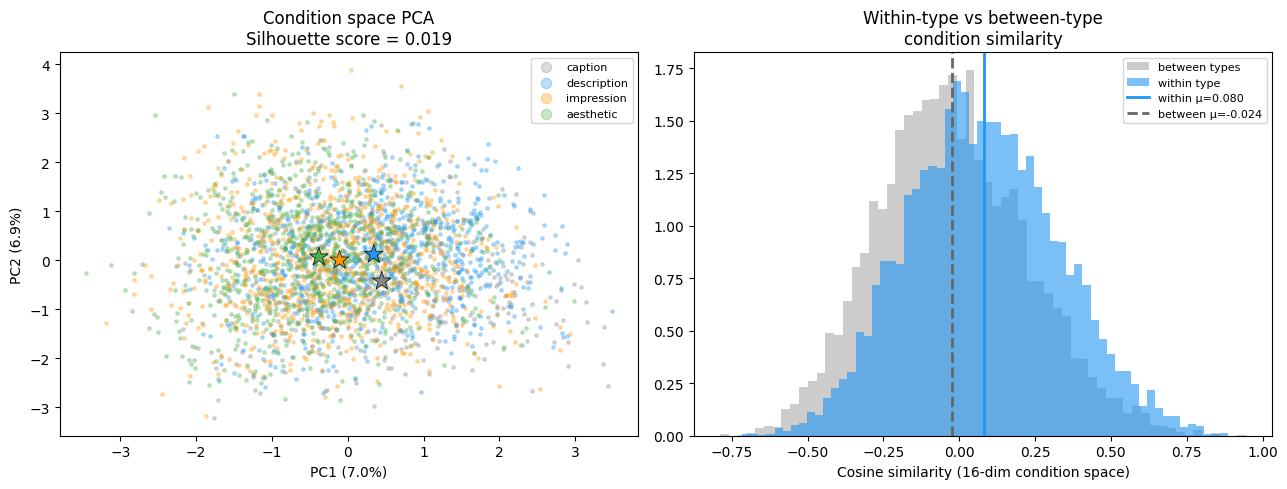

Condition space separability:
  Silhouette score  : 0.0188  (0=random, 1=perfect)
  Within-type μ cos : 0.0801
  Between-type μ cos: -0.0241
  Cohen's d         : 0.4207
  Mann-Whitney p    : 4.26e-148  (H1: within > between)


In [5]:
# ── 1A: Condition-space geometry ──────────────────────────────────────────────
N_sub = min(3000, label_emb_all.shape[0])
torch.manual_seed(0); idx_s = torch.randperm(label_emb_all.shape[0])[:N_sub]
conds_sub  = label_emb_all[idx_s].numpy()   # [N_sub, 16]
types_sub  = train_types[idx_s].numpy()

pca2 = PCA(n_components=2).fit(conds_sub)
pc2  = pca2.transform(conds_sub)

# Silhouette score
sil = silhouette_score(conds_sub, types_sub, sample_size=min(2000, N_sub), random_state=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for t in range(4):
    m = types_sub == t
    ax.scatter(pc2[m,0], pc2[m,1], s=6, alpha=0.3, color=TYPE_COLORS[t], label=TYPE_NAMES[t])
ax.scatter(*pca2.transform(type_means.numpy()).T,
           s=200, marker="*", c=TYPE_COLORS, zorder=5, edgecolors="k", linewidths=0.5)
ax.set_title(f"Condition space PCA\nSilhouette score = {sil:.3f}")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(fontsize=8, markerscale=3)

# ── Within vs between type cosine similarity in condition space ───────────────
conds_n = F.normalize(torch.tensor(conds_sub), dim=-1).numpy()
np.random.seed(42)
N_PAIRS = 8000
within_cs, between_cs = [], []
for _ in range(N_PAIRS):
    t = np.random.randint(4)
    idx_t = np.where(types_sub == t)[0]
    if len(idx_t) < 2: continue
    i, j = np.random.choice(idx_t, 2, replace=False)
    within_cs.append(float(np.dot(conds_n[i], conds_n[j])))

    t1, t2 = np.random.choice(4, 2, replace=False)
    i2 = np.random.choice(np.where(types_sub == t1)[0])
    j2 = np.random.choice(np.where(types_sub == t2)[0])
    between_cs.append(float(np.dot(conds_n[i2], conds_n[j2])))

ax2 = axes[1]
ax2.hist(between_cs, bins=60, alpha=0.6, color="#aaa", label="between types", density=True)
ax2.hist(within_cs,  bins=60, alpha=0.6, color="#2196F3", label="within type",  density=True)
ax2.axvline(np.mean(within_cs),  color="#2196F3", lw=2, label=f"within μ={np.mean(within_cs):.3f}")
ax2.axvline(np.mean(between_cs), color="#666",    lw=2, ls="--", label=f"between μ={np.mean(between_cs):.3f}")
ax2.set_xlabel("Cosine similarity (16-dim condition space)")
ax2.set_title("Within-type vs between-type\ncondition similarity")
ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()

stat_cs, p_cs = mannwhitneyu(within_cs, between_cs, alternative="greater")
d_cs = (np.mean(within_cs)-np.mean(between_cs)) / np.sqrt(
    (np.std(within_cs)**2 + np.std(between_cs)**2)/2)
print(f"Condition space separability:")
print(f"  Silhouette score  : {sil:.4f}  (0=random, 1=perfect)")
print(f"  Within-type μ cos : {np.mean(within_cs):.4f}")
print(f"  Between-type μ cos: {np.mean(between_cs):.4f}")
print(f"  Cohen's d         : {d_cs:.4f}")
print(f"  Mann-Whitney p    : {p_cs:.2e}  (H1: within > between)")

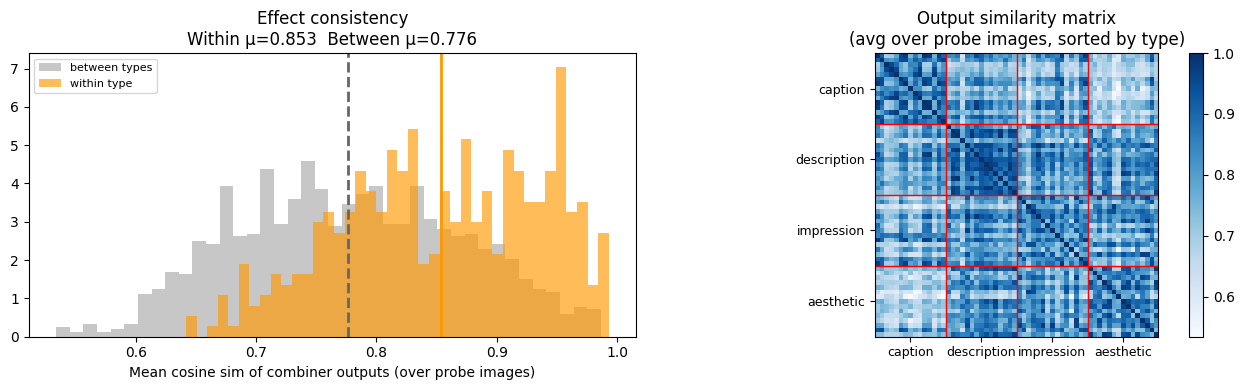

Effect consistency (combiner output space):
  Within-type output μ cos : 0.8534
  Between-type output μ cos: 0.7761
  Cohen's d: 0.8764  |  p: 2.80e-45


In [6]:
# ── 1B: Effect consistency — do same-type conditions move images similarly? ────
probe_emb = combine_emb[:N_PROBE]
np.random.seed(7); torch.manual_seed(7)

sampled_conds, sampled_types = [], []
for t in range(4):
    tc = label_emb_all[train_types == t]
    n  = min(N_PER_TYPE, len(tc))
    sampled_conds.append(tc[torch.randperm(len(tc))[:n]])
    sampled_types.extend([t]*n)
all_sc     = torch.cat(sampled_conds)          # [4*N_PER_TYPE, 16]
all_st     = torch.tensor(sampled_types)        # [4*N_PER_TYPE]
N_sc       = len(all_sc)

# Combiner outputs for all sampled conditions on probe images
sc_outputs = torch.stack([apply_cond(probe_emb, all_sc[ci:ci+1])
                           for ci in range(N_sc)])   # [N_sc, N_probe, 512]
sc_out_n   = F.normalize(sc_outputs, dim=-1)

# Mean cosine similarity between outputs (averaged over probe images)
# [N_probe, N_sc, 512] bmm [N_probe, 512, N_sc] → [N_probe, N_sc, N_sc]
avg_sim_mat = torch.bmm(
    sc_out_n.permute(1,0,2),
    sc_out_n.permute(1,2,0)
).mean(0).numpy()   # [N_sc, N_sc]

within_es, between_es = [], []
for i in range(N_sc):
    for j in range(i+1, N_sc):
        v = avg_sim_mat[i, j]
        (within_es if all_st[i]==all_st[j] else between_es).append(v)

stat_es, p_es = mannwhitneyu(within_es, between_es, alternative="greater")
d_es = (np.mean(within_es)-np.mean(between_es)) / np.sqrt(
    (np.std(within_es)**2 + np.std(between_es)**2)/2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(between_es, bins=40, alpha=0.65, color="#aaa",    label="between types", density=True)
ax.hist(within_es,  bins=40, alpha=0.65, color="#FF9800", label="within type",   density=True)
ax.axvline(np.mean(within_es),  color="#FF9800", lw=2)
ax.axvline(np.mean(between_es), color="#666",    lw=2, ls="--")
ax.set_xlabel("Mean cosine sim of combiner outputs (over probe images)")
ax.set_title(f"Effect consistency\nWithin μ={np.mean(within_es):.3f}  Between μ={np.mean(between_es):.3f}")
ax.legend(fontsize=8)

# Per-type: N_sc×N_sc heatmap with type separators
ax2 = axes[1]
im  = ax2.imshow(avg_sim_mat, cmap="Blues", vmin=avg_sim_mat.min(), vmax=1)
# Draw type boundaries
boundaries = np.cumsum([N_PER_TYPE]*4) - 0.5
for b in boundaries[:-1]:
    ax2.axhline(b, color="red", lw=1); ax2.axvline(b, color="red", lw=1)
tick_pos = [i*N_PER_TYPE + N_PER_TYPE//2 for i in range(4)]
ax2.set_xticks(tick_pos); ax2.set_xticklabels(TYPE_NAMES, fontsize=9)
ax2.set_yticks(tick_pos); ax2.set_yticklabels(TYPE_NAMES, fontsize=9)
ax2.set_title("Output similarity matrix\n(avg over probe images, sorted by type)")
plt.colorbar(im, ax=ax2)

plt.tight_layout(); plt.show()

print(f"Effect consistency (combiner output space):")
print(f"  Within-type output μ cos : {np.mean(within_es):.4f}")
print(f"  Between-type output μ cos: {np.mean(between_es):.4f}")
print(f"  Cohen's d: {d_es:.4f}  |  p: {p_es:.2e}")

---
## 2 — Q2: Do Condition Types Match Query Types?

**2A** — 4×4 R@1 matrix: which *condition type* best serves each *query type*?  
If diagonal ≫ off-diagonal, conditioning is type-discriminative end-to-end.  
**2B** — Delta directions: do different types push image embeddings in distinct directions?

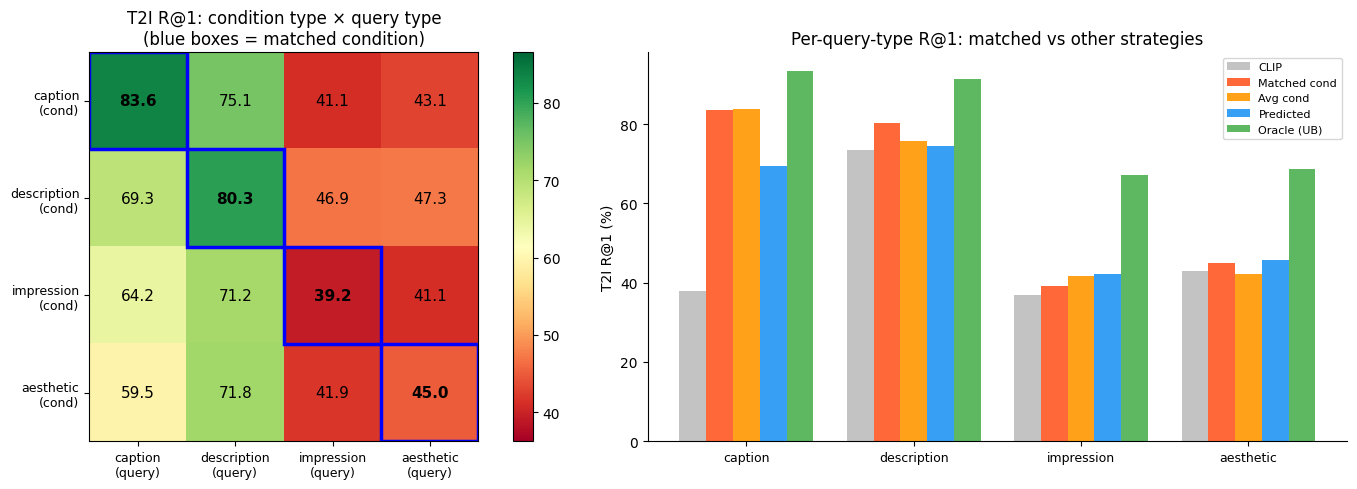

Condition × query R@1 matrix:
               caption  description   impression    aesthetic
  caption        83.6%        75.1%        41.1%        43.1%
  description      69.3%        80.3%        46.9%        47.3%
  impression      64.2%        71.2%        39.2%        41.1%
  aesthetic      59.5%        71.8%        41.9%        45.0%

Diagonal (matched) mean:  62.0%
Off-diagonal mean:         56.0%
Mean diagonal advantage:   +6.0pp
Best condition per query:  ['caption', 'description', 'description', 'description']
Matched is best for:       2/4 query types
Binomial p-value (vs chance 1/4): 0.2617


In [7]:
# ── 2A: Condition × query type R@1 matrix ─────────────────────────────────────
type_idx = [(test_cap_types == t).nonzero(as_tuple=True)[0] for t in range(4)]

def r1_per_query_type(out_n):
    sims = comb_t2i(out_n)
    return [r_at_k(t2i_ranks_subset(sims, type_idx[t]), 1) for t in range(4)]

cond_query_mat = np.array([r1_per_query_type(F.normalize(type_cond_out[c], dim=-1))
                            for c in range(4)])
clip_per_type  = [r_at_k(t2i_ranks_subset(sims_clip, type_idx[t]), 1) for t in range(4)]
avg_per_type   = r1_per_query_type(out_avg)
pred_per_type  = r1_per_query_type(out_pred_n) if out_pred_n is not None else None
oracle_per_type = [r_at_k(per_rep_gt_rank[:, type_idx[t]].min(0).values, 1)
                   for t in range(4)] if HAS_CA else None

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
im = ax.imshow(cond_query_mat, cmap="RdYlGn",
               vmin=cond_query_mat.min()-3, vmax=cond_query_mat.max()+3)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{cond_query_mat[i,j]:.1f}",
                ha="center", va="center", fontsize=11,
                fontweight="bold" if i==j else "normal")
    ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1,
                                fill=False, edgecolor="blue", lw=2.5))
ax.set_xticks(range(4)); ax.set_xticklabels([f"{n}\n(query)" for n in TYPE_NAMES], fontsize=9)
ax.set_yticks(range(4)); ax.set_yticklabels([f"{n}\n(cond)"  for n in TYPE_NAMES], fontsize=9)
ax.set_title("T2I R@1: condition type × query type\n(blue boxes = matched condition)")
plt.colorbar(im, ax=ax)

ax2 = axes[1]
x = np.arange(4); w = 0.16
ax2.bar(x - 2*w, clip_per_type, width=w, label="CLIP",         color="#bdbdbd", alpha=0.9)
ax2.bar(x -   w, [cond_query_mat[t,t] for t in range(4)],
                                          width=w, label="Matched cond",  color="#FF5722", alpha=0.9)
ax2.bar(x,       avg_per_type, width=w,   label="Avg cond",     color="#FF9800", alpha=0.9)
if pred_per_type:
    ax2.bar(x +   w, pred_per_type,       width=w, label="Predicted",    color="#2196F3", alpha=0.9)
if oracle_per_type:
    ax2.bar(x + 2*w, oracle_per_type,     width=w, label="Oracle (UB)",  color="#4CAF50", alpha=0.9)
ax2.set_xticks(x); ax2.set_xticklabels(TYPE_NAMES, fontsize=9)
ax2.set_ylabel("T2I R@1 (%)"); ax2.legend(fontsize=8)
ax2.set_title("Per-query-type R@1: matched vs other strategies")
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

diag_vals    = [cond_query_mat[t, t] for t in range(4)]
offdiag_vals = [cond_query_mat[i,j] for i in range(4) for j in range(4) if i!=j]
best_for_q   = [int(cond_query_mat[:,t].argmax()) for t in range(4)]
n_diag_best  = sum(best_for_q[t]==t for t in range(4))

print("Condition × query R@1 matrix:")
print("           " + "  ".join(f"{n:>11}" for n in TYPE_NAMES))
for i in range(4):
    print(f"  {TYPE_NAMES[i]:<9}" + "  ".join(f"{cond_query_mat[i,j]:>10.1f}%" for j in range(4)))
print(f"\nDiagonal (matched) mean:  {np.mean(diag_vals):.1f}%")
print(f"Off-diagonal mean:         {np.mean(offdiag_vals):.1f}%")
print(f"Mean diagonal advantage:   {np.mean(diag_vals)-np.mean(offdiag_vals):+.1f}pp")
print(f"Best condition per query:  {[TYPE_NAMES[b] for b in best_for_q]}")
print(f"Matched is best for:       {n_diag_best}/4 query types")
result_bt = binomtest(n_diag_best, n=4, p=0.25, alternative="greater")
print(f"Binomial p-value (vs chance 1/4): {result_bt.pvalue:.4f}")


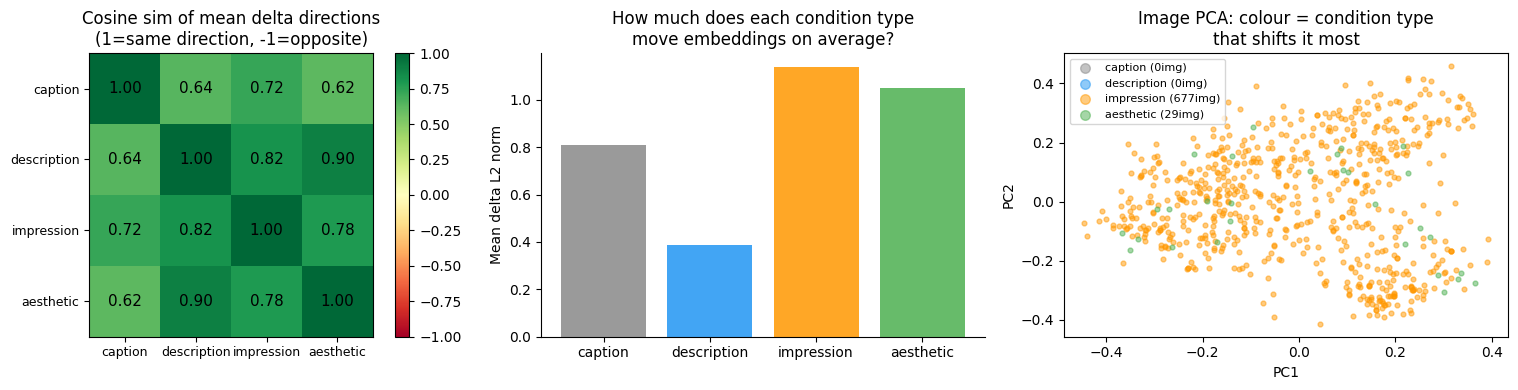

Mean delta norms (how much each condition type moves embeddings):
  caption       : 0.8076
  description   : 0.3862
  impression    : 1.1404
  aesthetic     : 1.0522

Direction similarity (off-diagonal): mean=0.746  std=0.098
  High similarity → types push in same direction (low discrimination)
  Low similarity  → types push in distinct directions (high discrimination)


In [8]:
# ── 2B: Delta directions — do types push embeddings in different directions? ──
# Mean shift vector per condition type: E[combiner(img, cond_t) - img]
# Cosine similarity between shift directions reveals if types are distinct.

img_n_mat = F.normalize(combine_emb, dim=-1)  # [N_combine, 512]

delta_means = []
delta_norms = []
for t in range(4):
    delta = type_cond_out[t] - img_n_mat   # [N_img, 512]
    delta_means.append(delta.mean(0))       # [512]
    delta_norms.append(delta.norm(dim=-1).mean().item())

delta_means_t = torch.stack(delta_means)   # [4, 512]
dm_n = F.normalize(delta_means_t, dim=-1)
dir_sim = (dm_n @ dm_n.T).numpy()         # [4, 4] cosine sim between mean directions

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Direction similarity heatmap
ax = axes[0]
im = ax.imshow(dir_sim, cmap="RdYlGn", vmin=-1, vmax=1)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{dir_sim[i,j]:.2f}", ha="center", va="center", fontsize=11)
ax.set_xticks(range(4)); ax.set_xticklabels(TYPE_NAMES, fontsize=9)
ax.set_yticks(range(4)); ax.set_yticklabels(TYPE_NAMES, fontsize=9)
ax.set_title("Cosine sim of mean delta directions\n(1=same direction, -1=opposite)")
plt.colorbar(im, ax=ax)

# Mean delta magnitude per type
ax2 = axes[1]
ax2.bar(TYPE_NAMES, delta_norms, color=TYPE_COLORS, alpha=0.85)
ax2.set_ylabel("Mean delta L2 norm")
ax2.set_title("How much does each condition type\nmove embeddings on average?")
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

# PCA of per-image deltas coloured by which type produces largest shift
all_deltas = torch.stack([type_cond_out[t] - img_n_mat for t in range(4)])
# all_deltas: [4, N_img, 512]
dominant_type = all_deltas.norm(dim=-1).argmax(dim=0).numpy()  # [N_img]
pca_d = PCA(n_components=2).fit_transform(img_n_mat.numpy())
ax3 = axes[2]
for t in range(4):
    m = dominant_type == t
    ax3.scatter(pca_d[m,0], pca_d[m,1], s=12, alpha=0.5, color=TYPE_COLORS[t],
                label=f"{TYPE_NAMES[t]} ({m.sum()}img)")
ax3.set_title("Image PCA: colour = condition type\nthat shifts it most")
ax3.legend(fontsize=8, markerscale=2)
ax3.set_xlabel("PC1"); ax3.set_ylabel("PC2")

plt.tight_layout(); plt.show()

print("Mean delta norms (how much each condition type moves embeddings):")
for t in range(4):
    print(f"  {TYPE_NAMES[t]:<14}: {delta_norms[t]:.4f}")

off_diag_dir = [dir_sim[i,j] for i in range(4) for j in range(4) if i!=j]
print(f"\nDirection similarity (off-diagonal): mean={np.mean(off_diag_dir):.3f}  "
      f"std={np.std(off_diag_dir):.3f}")
print(f"  High similarity → types push in same direction (low discrimination)")
print(f"  Low similarity  → types push in distinct directions (high discrimination)")

---
## 3 — Q3: Do Conditions Carry Real Information?

Three null hypotheses tested via permutation/random-assignment:

| Null | What it breaks | Rejects → |
|---|---|---|
| Shuffle predicted outputs (break image↔condition pairing) | Image specificity | Predictor assigns image-specific conditions |
| Random representative per image | Per-image rep choice | Specific rep matters for each image |
| Gaussian noise conditions | All structure | Any learned condition beats noise |

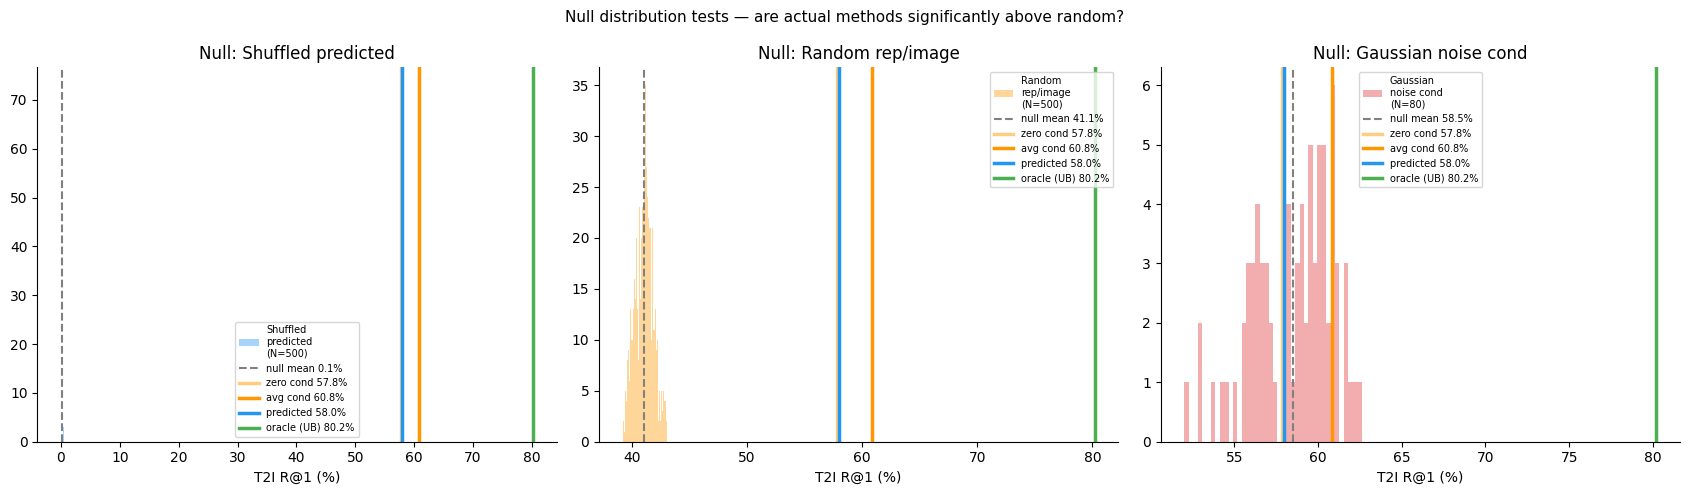


Method               vs Null1 (shuffled pred)      vs Null2 (rand rep)         vs Null3 (noise)    
                        z     pct        z     pct        z     pct
----------------------------------------------------------------------------------------------
  zero cond        +555.31  100.0%   +21.51  100.0%    -0.28   35.0%
  avg cond         +584.29  100.0%   +25.37  100.0%    +1.00   83.8%
  predicted        +556.67  100.0%   +21.69  100.0%    -0.22   36.2%
  oracle           +770.76  100.0%   +50.22  100.0%    +9.19  100.0%


In [9]:
torch.manual_seed(42); np.random.seed(42)

def full_t2i_r1(out_n):
    sims = comb_t2i(out_n)
    return r_at_k(t2i_ranks_from_sims(sims), 1)

# ── Null 1: Shuffle predicted combiner outputs (no new combiner calls) ─────────
null1_r1 = []
if out_pred_n is not None:
    for _ in range(N_BOOT):
        perm = torch.randperm(n_img)
        null1_r1.append(full_t2i_r1(out_pred_n[perm]))

# ── Null 2: Random representative assignment per image ─────────────────────────
null2_r1 = []
for _ in range(N_BOOT):
    ri  = torch.randint(0, K, (n_img,))
    out = per_rep_comb_out[ri, torch.arange(n_img)]          # [n_img, 512]
    null2_r1.append(full_t2i_r1(F.normalize(out, dim=-1)))

# ── Null 3: Gaussian noise conditions (N=80 samples, each re-runs combiner) ────
cond_std = label_emb_all.std().item()
null3_r1 = []
for _ in range(80):
    noise = torch.randn(1, label_dim) * cond_std
    out_n = apply_cond(combine_emb, noise)
    null3_r1.append(full_t2i_r1(out_n))

# ── Actual method values ───────────────────────────────────────────────────────
r1_zero   = full_t2i_r1(out_zero)
r1_avg    = full_t2i_r1(out_avg)
r1_pred   = full_t2i_r1(out_pred_n) if out_pred_n is not None else None
r1_oracle = r_at_k(per_rep_gt_rank.min(0).values, 1) if HAS_CA else None
r1_type   = {TYPE_NAMES[t]: full_t2i_r1(F.normalize(type_cond_out[t], dim=-1))
             for t in range(4)}

# ── Visualisation ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

null_labels = []
null_data   = []
null_colors = []
if null1_r1: null_labels.append("Shuffled\npredicted"); null_data.append(null1_r1); null_colors.append("#90CAF9")
null_labels.append("Random\nrep/image"); null_data.append(null2_r1); null_colors.append("#FFCC80")
null_labels.append("Gaussian\nnoise cond"); null_data.append(null3_r1); null_colors.append("#EF9A9A")

for ax_i, (ax, nd, nl, nc) in enumerate(zip(axes, null_data, null_labels, null_colors)):
    ax.hist(nd, bins=40, color=nc, alpha=0.8, label=f"{nl}\n(N={len(nd)})")
    ax.axvline(np.mean(nd), color="gray", lw=1.5, ls="--",
               label=f"null mean {np.mean(nd):.1f}%")
    # Actual methods
    styles = [(r1_zero,"zero cond","#FFCC80"), (r1_avg,"avg cond","#FF9800")]
    if r1_pred:   styles.append((r1_pred,  "predicted", "#2196F3"))
    if r1_oracle: styles.append((r1_oracle,"oracle (UB)","#4CAF50"))
    for val, lbl, col in styles:
        if val is not None:
            ax.axvline(val, color=col, lw=2.5, label=f"{lbl} {val:.1f}%")
    ax.set_xlabel("T2I R@1 (%)"); ax.legend(fontsize=7)
    ax.set_title(f"Null: {nl.replace(chr(10),' ')}")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.suptitle("Null distribution tests — are actual methods significantly above random?",
             fontsize=11)
plt.tight_layout(); plt.show()

# ── Z-scores ──────────────────────────────────────────────────────────────────
def z_and_pct(val, null):
    if val is None or len(null)==0: return None, None
    z = (val - np.mean(null)) / (np.std(null) + 1e-8)
    pct = (np.array(null) < val).mean() * 100
    return z, pct

print(f"\n{'Method':<18} {'vs Null1 (shuffled pred)':^28} {'vs Null2 (rand rep)':^26} {'vs Null3 (noise)':^24}")
print(f"{'':18} {'z':>6}  {'pct':>6}   {'z':>6}  {'pct':>6}   {'z':>6}  {'pct':>6}")
print("-" * 94)
for val, lbl in [(r1_zero,"zero cond"), (r1_avg,"avg cond"),
                  (r1_pred,"predicted"), (r1_oracle,"oracle")]:
    if val is None: continue
    z1,p1 = z_and_pct(val, null1_r1) if null1_r1 else (None, None)
    z2,p2 = z_and_pct(val, null2_r1)
    z3,p3 = z_and_pct(val, null3_r1)
    def fmt(z, p): return f"{z:>+6.2f}  {p:>5.1f}%" if z is not None else f"{'n/a':>14}"
    print(f"  {lbl:<16} {fmt(z1,p1)}   {fmt(z2,p2)}   {fmt(z3,p3)}")

---
## 4 — Predictor Specificity

Is the predictor learning **per-image** conditions, or just a fixed global condition?  
What type does each predicted condition most resemble?

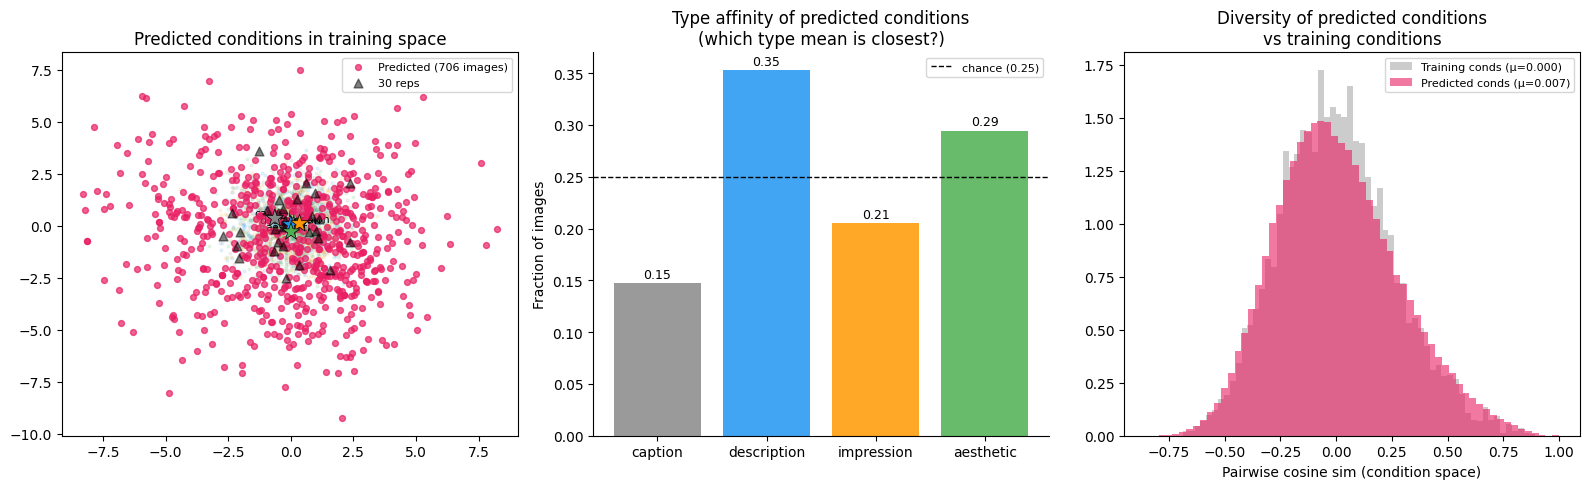

Predictor type-affinity vs oracle type agreement: 31.4%  (chance: 25%)
Diversity of predicted conditions (pairwise cos): mean=0.0066
Diversity of training conditions (pairwise cos):  mean=0.0001
  → Predicted conditions are LESS diverse than training (possible mode collapse)
Type affinity fractions: {'caption': '0.15', 'description': '0.35', 'impression': '0.21', 'aesthetic': '0.29'}


In [10]:
if raw_pred is None:
    print("No predictor — section skipped.")
else:
    # ── PCA of predicted conditions ────────────────────────────────────────────
    pca_p = PCA(n_components=2)
    # Fit on training conditions
    all_tr_sub = label_emb_all[torch.randperm(len(label_emb_all))[:2000]].numpy()
    pca_p.fit(all_tr_sub)
    pred_pc  = pca_p.transform(raw_pred.numpy())
    rep_pc   = pca_p.transform(representatives.numpy())
    type_pc  = pca_p.transform(type_means.numpy())

    # ── Type affinity of predicted conditions ──────────────────────────────────
    pred_n      = F.normalize(raw_pred, dim=-1)                # [N_img, 16]
    type_means_n= F.normalize(type_means, dim=-1)              # [4, 16]
    sim_to_types = (pred_n @ type_means_n.T).numpy()           # [N_img, 4]
    dominant_t   = sim_to_types.argmax(axis=1)                 # [N_img] — closest type mean
    type_frac    = [(dominant_t == t).mean() for t in range(4)]

    # ── Per-image diversity: how variable are predicted conditions? ────────────
    pred_pairwise_sim = (pred_n @ pred_n.T).numpy()
    iu = np.triu_indices(n_img, 1)
    pred_pw_vals = pred_pairwise_sim[iu]
    # Compare to: same-image pairs (trivially 1), random pairs in training
    idx_rnd = np.random.choice(len(label_emb_all), (2000,), replace=False)
    tr_n    = F.normalize(label_emb_all[idx_rnd], dim=-1).numpy()
    tr_pw   = (tr_n @ tr_n.T)[np.triu_indices(2000, 1)]

    # ── Visualise ─────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # PCA: predicted conditions vs training backdrop + type means
    ax = axes[0]
    tr_types_sub = train_types[torch.randperm(len(train_types))[:2000]].numpy()
    tr_pc2 = pca_p.transform(all_tr_sub)
    for t in range(4):
        m = tr_types_sub == t
        ax.scatter(tr_pc2[m,0], tr_pc2[m,1], s=4, alpha=0.1, color=TYPE_COLORS[t])
    ax.scatter(pred_pc[:,0], pred_pc[:,1], s=18, alpha=0.7, color="#e91e63",
               label=f"Predicted ({n_img} images)", zorder=4)
    ax.scatter(type_pc[:,0], type_pc[:,1], s=180, marker="*",
               c=TYPE_COLORS, zorder=6, edgecolors="k", linewidths=0.5)
    for t in range(4):
        ax.annotate(TYPE_NAMES[t], type_pc[t], fontsize=8, ha="center", va="bottom")
    ax.scatter(rep_pc[:,0], rep_pc[:,1], s=40, marker="^", color="k",
               zorder=5, alpha=0.5, label=f"{K} reps")
    ax.set_title("Predicted conditions in training space"); ax.legend(fontsize=8)

    # Type affinity distribution
    ax2 = axes[1]
    ax2.bar(TYPE_NAMES, type_frac, color=TYPE_COLORS, alpha=0.85)
    ax2.axhline(0.25, color="k", ls="--", lw=1, label="chance (0.25)")
    ax2.set_ylabel("Fraction of images")
    ax2.set_title("Type affinity of predicted conditions\n(which type mean is closest?)")
    ax2.legend(fontsize=8)
    for i, v in enumerate(type_frac):
        ax2.text(i, v+0.005, f"{v:.2f}", ha="center", fontsize=9)
    ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

    # Predicted pairwise similarity vs training
    ax3 = axes[2]
    ax3.hist(tr_pw[:5000], bins=60, alpha=0.6, color="#aaa",
             label=f"Training conds (μ={tr_pw.mean():.3f})", density=True)
    ax3.hist(pred_pw_vals, bins=60, alpha=0.6, color="#e91e63",
             label=f"Predicted conds (μ={pred_pw_vals.mean():.3f})", density=True)
    ax3.set_xlabel("Pairwise cosine sim (condition space)")
    ax3.set_title("Diversity of predicted conditions\nvs training conditions")
    ax3.legend(fontsize=8)

    plt.tight_layout(); plt.show()

    # ── Per-type: does predictor output match the oracle type? ────────────────
    # Oracle condition per image: which representative is best for any of its GTs?
    if HAS_CA:
        oracle_rep_per_img = per_rep_gt_rank[:, img2txt[:,0]].argmin(0).numpy()  # [N_img]
        # Which type-mean is each oracle rep closest to?
        reps_n   = F.normalize(representatives, dim=-1)
        rep_type_affinity = (reps_n @ type_means_n.T).argmax(dim=1).numpy()  # [K]
        oracle_type = rep_type_affinity[oracle_rep_per_img]                   # [N_img]

        # Agreement: does predicted dominant type == oracle type?
        agreement = (dominant_t == oracle_type).mean()
        print(f"Predictor type-affinity vs oracle type agreement: {agreement*100:.1f}%  "
              f"(chance: 25%)")
        print(f"Diversity of predicted conditions (pairwise cos): mean={pred_pw_vals.mean():.4f}")
        print(f"Diversity of training conditions (pairwise cos):  mean={tr_pw.mean():.4f}")
        if pred_pw_vals.mean() > tr_pw.mean() * 1.2:
            print("  → Predicted conditions are LESS diverse than training (possible mode collapse)")
        elif pred_pw_vals.mean() < tr_pw.mean() * 0.8:
            print("  → Predicted conditions are MORE diverse than training (good coverage)")
        else:
            print("  → Predicted conditions have similar diversity to training")
    print(f"Type affinity fractions: {dict(zip(TYPE_NAMES, [f'{v:.2f}' for v in type_frac]))}")

---
## 5 — Aggregation Strategies

Compares 7 per-image condition strategies across all 4 query types and the full query set.  
All strategies use the **same trained combiner** — only *how the condition is constructed* differs.

| Strategy | Description |
|---|---|
| zero | Zero condition (combiner with no signal) |
| avg_all | Average of all 4 type-mean conditions |
| type_t | Single type-mean for each of the 4 types |
| nearest_rep | Use the representative closest to predicted condition |
| top2_ensemble | Average output of top-2 closest representatives |
| type_weighted | Weighted blend of 4 type outputs (weights from predictor affinity) |
| predicted | Raw per-image predicted condition |
| oracle (UB) | Best representative per query (upper bound, not deployable) |

In [11]:
# ── Build all strategy outputs ─────────────────────────────────────────────────
strategies = {}

# Zero
strategies["zero"] = out_zero

# Avg all types
strategies["avg_all"] = out_avg

# Single type means
for t in range(4):
    strategies[f"type_{TYPE_NAMES[t][:3]}"] = F.normalize(type_cond_out[t], dim=-1)

if raw_pred is not None:
    # Predicted
    strategies["predicted"] = out_pred_n

    # Nearest representative (based on predicted condition similarity)
    pred_n_16   = F.normalize(raw_pred, dim=-1)           # [N_img, 16]
    reps_n_16   = F.normalize(representatives, dim=-1)    # [K, 16]
    sim_reps    = pred_n_16 @ reps_n_16.T                 # [N_img, K]
    nearest_idx = sim_reps.argmax(dim=1)                  # [N_img]
    out_nearest = per_rep_comb_out[nearest_idx, torch.arange(n_img)]  # [N_img, 512]
    strategies["nearest_rep"] = F.normalize(out_nearest, dim=-1)

    # Top-2 ensemble
    top2_idx = sim_reps.topk(2, dim=1).indices            # [N_img, 2]
    out_top2 = (per_rep_comb_out[top2_idx[:,0], torch.arange(n_img)] +
                per_rep_comb_out[top2_idx[:,1], torch.arange(n_img)]) / 2
    strategies["top2_ensemble"] = F.normalize(out_top2, dim=-1)

    # Type-weighted: weight type_cond_out[t] by predictor affinity to each type mean
    type_means_n16 = F.normalize(type_means, dim=-1)      # [4, 16]
    type_weights   = F.softmax(pred_n_16 @ type_means_n16.T * 5, dim=-1)  # [N_img, 4]
    # Blend type outputs: [N_img, 512]
    out_tw = sum(type_weights[:,t:t+1] * F.normalize(type_cond_out[t], dim=-1)
                 for t in range(4))
    strategies["type_weighted"] = F.normalize(out_tw, dim=-1)

# Oracle upper bound
if HAS_CA:
    oracle_rep_per_img = per_rep_gt_rank[:, img2txt[:,0]].argmin(0)  # [N_img]
    out_oracle = per_rep_comb_out[oracle_rep_per_img, torch.arange(n_img)]
    strategies["oracle_UB"] = F.normalize(out_oracle, dim=-1)

# ── Evaluate all strategies ────────────────────────────────────────────────────
# For each strategy: R@1 per query type + all types combined
eval_subsets = [(f"all", torch.arange(n_txt))] + \
               [(TYPE_NAMES[t], type_idx[t]) for t in range(4)]

results = {}  # {strategy: {subset_name: R@1}}
for sname, out in strategies.items():
    out_n  = F.normalize(out, dim=-1)
    sims   = comb_t2i(out_n)
    results[sname] = {}
    for ss_name, ti in eval_subsets:
        ranks = t2i_ranks_subset(sims, ti)
        results[sname][ss_name] = r_at_k(ranks, 1)

# ── Print table ────────────────────────────────────────────────────────────────
print(f"{'Strategy':<18}  "
      + "  ".join(f"{n:>12}" for n, _ in eval_subsets))
print("-" * (18 + 14 * len(eval_subsets)))
for sname in strategies:
    suffix = "  ← UB" if "oracle" in sname else ""
    row = [results[sname][n] for n, _ in eval_subsets]
    print(f"  {sname:<16}  " + "  ".join(f"{v:>11.1f}%" for v in row) + suffix)

Strategy                     all       caption   description    impression     aesthetic
----------------------------------------------------------------------------------------
  zero                     57.8%         68.3%         75.2%         42.8%         45.0%
  avg_all                  60.8%         83.9%         75.6%         41.6%         42.2%
  type_cap                 60.7%         83.6%         75.1%         41.1%         43.1%
  type_des                 60.9%         69.3%         80.3%         46.9%         47.3%
  type_imp                 53.9%         64.2%         71.2%         39.2%         41.1%
  type_aes                 54.6%         59.5%         71.8%         41.9%         45.0%
  predicted                58.0%         69.5%         74.5%         42.2%         45.6%
  nearest_rep              45.4%         50.7%         61.6%         34.3%         35.0%
  top2_ensemble            54.7%         63.3%         70.1%         42.6%         42.8%
  type_weighted      

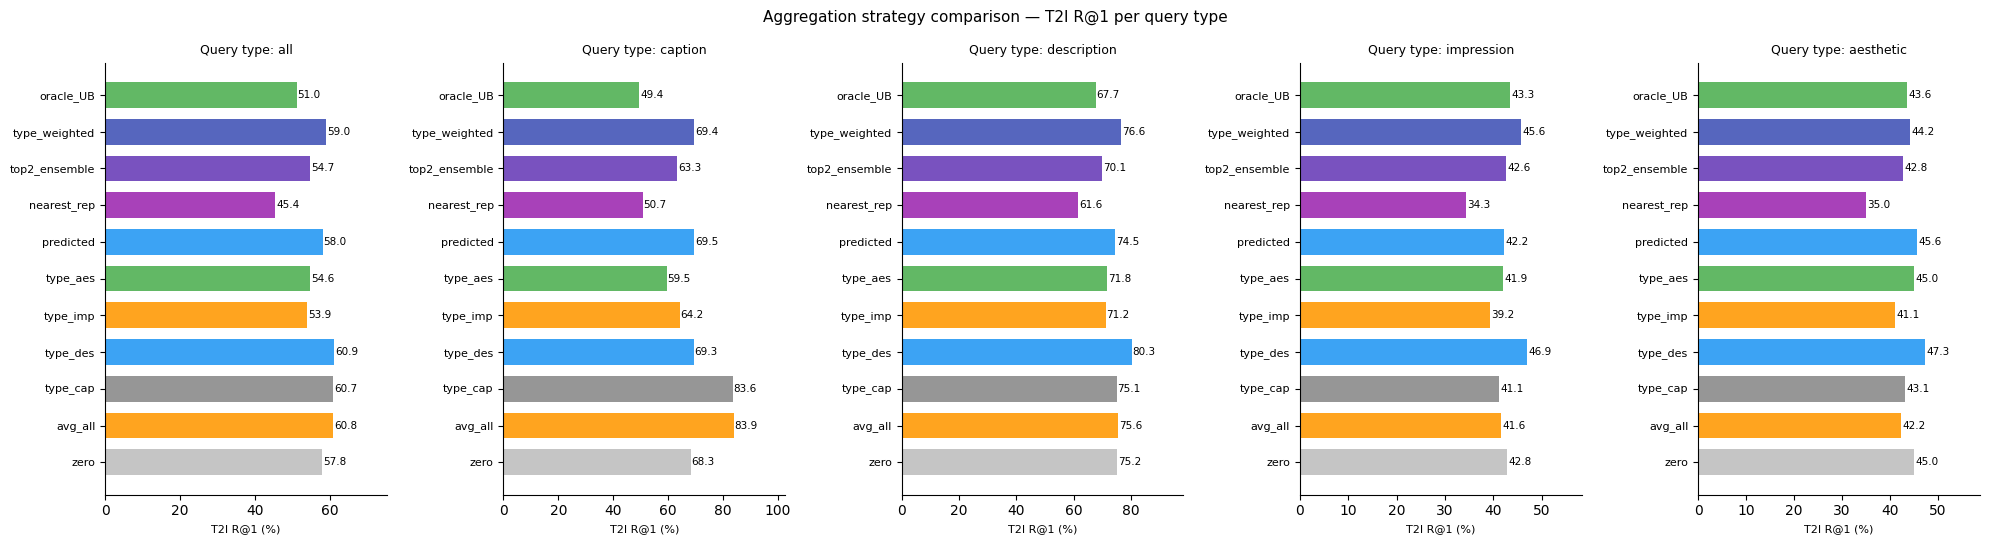

\nStrategies ranked by overall T2I R@1 (no oracle):
  #1  type_des            overall=60.9%  capt=69.3  desc=80.3  impr=46.9  aest=47.3
  #2  avg_all             overall=60.8%  capt=83.9  desc=75.6  impr=41.6  aest=42.2
  #3  type_cap            overall=60.7%  capt=83.6  desc=75.1  impr=41.1  aest=43.1
  #4  type_weighted       overall=59.0%  capt=69.4  desc=76.6  impr=45.6  aest=44.2
  #5  predicted           overall=58.0%  capt=69.5  desc=74.5  impr=42.2  aest=45.6
  #6  zero                overall=57.8%  capt=68.3  desc=75.2  impr=42.8  aest=45.0
  #7  top2_ensemble       overall=54.7%  capt=63.3  desc=70.1  impr=42.6  aest=42.8
  #8  type_aes            overall=54.6%  capt=59.5  desc=71.8  impr=41.9  aest=45.0
  #9  type_imp            overall=53.9%  capt=64.2  desc=71.2  impr=39.2  aest=41.1
  #10  nearest_rep         overall=45.4%  capt=50.7  desc=61.6  impr=34.3  aest=35.0


In [12]:
# ── Visualise aggregation strategies ─────────────────────────────────────────
strat_names = list(strategies.keys())
subset_names_eval = [n for n, _ in eval_subsets]

type_prefixes = [TYPE_NAMES[t][:3] for t in range(4)]   # ["cap","des","imp","aes"]

def strat_color(s):
    if s == "zero":           return "#bdbdbd"
    if s == "avg_all":        return "#FF9800"
    if s == "predicted":      return "#2196F3"
    if s == "nearest_rep":    return "#9C27B0"
    if s == "top2_ensemble":  return "#673AB7"
    if s == "type_weighted":  return "#3F51B5"
    if "oracle" in s:         return "#4CAF50"
    # type_cap / type_des / type_imp / type_aes
    if s.startswith("type_"):
        suffix = s[5:]
        if suffix in type_prefixes:
            return TYPE_COLORS[type_prefixes.index(suffix)]
    return "#aaa"

fig, axes = plt.subplots(1, len(eval_subsets), figsize=(4*len(eval_subsets), 5.5),
                         sharey=False)
if len(eval_subsets) == 1: axes = [axes]

for ax, (ss_name, _) in zip(axes, eval_subsets):
    vals   = [results[s][ss_name] for s in strat_names]
    colors = [strat_color(s) for s in strat_names]
    ys     = range(len(strat_names))
    bars   = ax.barh(ys, vals, color=colors, alpha=0.88, height=0.7)
    ax.set_yticks(ys)
    ax.set_yticklabels(strat_names, fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.3, bar.get_y() + bar.get_height()/2,
                f"{v:.1f}", va="center", ha="left", fontsize=7.5)
    ax.set_xlabel("T2I R@1 (%)", fontsize=8)
    ax.set_title(f"Query type: {ss_name}", fontsize=9)
    ax.set_xlim(0, max(vals)*1.2 + 2)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.suptitle("Aggregation strategy comparison — T2I R@1 per query type", fontsize=11)
plt.tight_layout(); plt.show()

non_oracle = [s for s in strat_names if "oracle" not in s]
ranked = sorted(non_oracle, key=lambda s: results[s]["all"], reverse=True)
print("\\nStrategies ranked by overall T2I R@1 (no oracle):")
for rank_i, s in enumerate(ranked, 1):
    print(f"  #{rank_i}  {s:<18}  overall={results[s]['all']:.1f}%  "
          + "  ".join(f"{TYPE_NAMES[t][:4]}={results[s][TYPE_NAMES[t]]:.1f}" for t in range(4)))


---
## 6 — Automatic Statistical Summary

Rule-based conclusions from all tests. Thresholds are configurable.

In [13]:
THR = dict(
    sil_meaningful   = 0.10,
    sil_strong       = 0.25,
    d_meaningful     = 0.20,
    d_strong         = 0.50,
    p_sig            = 0.05,
    diag_adv         = 3.0,
    dir_sim_high     = 0.70,
    z_sig            = 2.0,
    pred_div_ratio   = 0.80,
    type_aff_uniform = 0.15,
)

print("━" * 72)
print("  AUTOMATIC STATISTICAL SUMMARY")
print("━" * 72)

# ── Q1 ─────────────────────────────────────────────────────────────────────────
print("\n▸ Q1 — ARE CONDITIONS TYPE-DISCRIMINATIVE?")
print("  (A) Condition space (16-dim vectors):")
if sil >= THR["sil_strong"]:
    print(f"    ✓✓ Strong type clustering: silhouette={sil:.3f} ≥ {THR['sil_strong']}")
    print(f"       Conditions from the same type occupy distinct regions of the 16-dim space.")
elif sil >= THR["sil_meaningful"]:
    print(f"    ✓  Moderate clustering: silhouette={sil:.3f} — types have some separation.")
else:
    print(f"    ✗  Weak/no clustering: silhouette={sil:.3f} — condition types overlap heavily.")

if p_cs < THR["p_sig"] and d_cs >= THR["d_meaningful"]:
    print(f"    ✓  Within-type cos ({np.mean(within_cs):.3f}) > between ({np.mean(between_cs):.3f})"
          f"  d={d_cs:.2f}  p={p_cs:.2e}")
else:
    print(f"    ~  Within/between not clearly separated (p={p_cs:.2e}, d={d_cs:.2f})")

print("  (B) Effect consistency (combiner outputs on probe images):")
if p_es < THR["p_sig"] and d_es >= THR["d_meaningful"]:
    print(f"    ✓  Same-type conditions produce more similar outputs: d={d_es:.2f}  p={p_es:.2e}")
    print(f"       Type conditions reliably push images in a consistent direction.")
else:
    print(f"    ✗  Same-type conditions do NOT produce consistently similar outputs "
          f"(d={d_es:.2f}, p={p_es:.2e}).")
    print(f"       Even if condition vectors cluster by type, their combiner effects are mixed.")

# ── Q2 ─────────────────────────────────────────────────────────────────────────
print("\n▸ Q2 — DO CONDITION TYPES MATCH QUERY TYPES?")
diag_adv_val = np.mean(diag_vals) - np.mean(offdiag_vals)
if diag_adv_val >= THR["diag_adv"]:
    print(f"    ✓✓ Matched condition outperforms off-diagonal by {diag_adv_val:+.1f}pp on average.")
    print(f"       Type-specific conditioning improves retrieval for the corresponding query type.")
elif diag_adv_val > 0:
    print(f"    ~  Matched condition advantage is marginal: {diag_adv_val:+.1f}pp.")
else:
    print(f"    ✗  Matched condition does NOT outperform mismatched: {diag_adv_val:+.1f}pp.")
    print(f"       Conditions are not text-type aware in their retrieval effect.")
print(f"       Best condition for each query: {dict(zip(TYPE_NAMES, [TYPE_NAMES[b] for b in best_for_q]))}")
print(f"       Matched is best for {n_diag_best}/4 query types  "
      f"(binomial p={result_bt.pvalue:.4f})")

mean_offdiag_dir = np.mean(off_diag_dir)
if mean_offdiag_dir >= THR["dir_sim_high"]:
    print(f"    ✗  Direction similarity between types = {mean_offdiag_dir:.3f}  "
          f"(all types push images in similar directions → low geometric discrimination)")
elif mean_offdiag_dir > 0.3:
    print(f"    ~  Direction similarity = {mean_offdiag_dir:.3f}  — partial overlap between type directions.")
else:
    print(f"    ✓  Direction similarity = {mean_offdiag_dir:.3f}  — types push in distinct directions.")

# ── Q3 ─────────────────────────────────────────────────────────────────────────
print("\n▸ Q3 — DO CONDITIONS CARRY REAL INFORMATION?")
z2_avg,  p2_avg  = z_and_pct(r1_avg,  null2_r1)
z2_pred, p2_pred = z_and_pct(r1_pred, null2_r1) if r1_pred else (None, None)

if z2_avg is not None and z2_avg >= THR["z_sig"]:
    print(f"    ✓✓ Avg condition above random-rep null: z={z2_avg:+.2f}  pct={p2_avg:.1f}%")
    print(f"       Using learned type-mean conditions beats any random representative.")
elif z2_avg is not None:
    print(f"    ~  Avg condition barely above random-rep null: z={z2_avg:+.2f}")

if null1_r1:
    z1_pred, p1_pred = z_and_pct(r1_pred, null1_r1)
    if z1_pred is not None and z1_pred >= THR["z_sig"]:
        print(f"    ✓✓ Predicted above shuffle-pred null: z={z1_pred:+.2f}  pct={p1_pred:.1f}%")
        print(f"       The predictor assigns image-SPECIFIC conditions that matter for retrieval.")
    elif z1_pred is not None and z1_pred > 0:
        print(f"    ~  Predicted marginally above shuffled: z={z1_pred:+.2f} — weak image-specificity.")
    elif z1_pred is not None:
        print(f"    ✗  Predicted NOT above shuffled (z={z1_pred:+.2f}): conditions are not image-specific.")

# ── Predictor ──────────────────────────────────────────────────────────────────
if raw_pred is not None:
    print("\n▸ PREDICTOR SPECIFICITY")
    div_ratio = pred_pw_vals.mean() / (tr_pw.mean() + 1e-8)
    if div_ratio < THR["pred_div_ratio"]:
        print(f"    ✗  Predicted conditions COLLAPSED (diversity ratio={div_ratio:.2f} < {THR['pred_div_ratio']}): "
              f"all images get nearly the same condition.")
    else:
        print(f"    ✓  Predicted conditions maintain diversity: ratio={div_ratio:.2f}")
    dom_type = int(np.argmax(type_frac))
    if max(type_frac) > 0.25 + THR["type_aff_uniform"]:
        print(f"    ⚑  Predictor biased toward '{TYPE_NAMES[dom_type]}' type "
              f"({max(type_frac)*100:.0f}% of images vs 25% expected).")
    else:
        print(f"    ~  Predictor type affinity roughly uniform.")

# ── Aggregation ────────────────────────────────────────────────────────────────
print("\n▸ AGGREGATION RECOMMENDATION")
best_d = ranked[0]
r1_b   = results[best_d]["all"]
r1_a   = results["avg_all"]["all"]
print(f"    Best deployable: '{best_d}'  overall R@1={r1_b:.1f}%")
gain_over_avg = r1_b - r1_a
if gain_over_avg >= 2.0:
    print(f"    ✓  Beats avg_all by {gain_over_avg:+.1f}pp — complexity is worthwhile.")
else:
    print(f"    ~  Only {gain_over_avg:+.1f}pp over avg_all — simple avg_all may be sufficient.")
if r1_oracle:
    gap = r1_oracle - r1_b
    tag = f"  ⚑  Large headroom ({gap:.1f}pp) — significant room to improve condition prediction." \
          if gap >= 10 else f"  ~  Moderate headroom ({gap:.1f}pp)."
    print(f"    Oracle UB: {r1_oracle:.1f}%  (headroom={gap:.1f}pp).{tag}")

print("\n" + "━" * 72)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  AUTOMATIC STATISTICAL SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

▸ Q1 — ARE CONDITIONS TYPE-DISCRIMINATIVE?
  (A) Condition space (16-dim vectors):
    ✗  Weak/no clustering: silhouette=0.019 — condition types overlap heavily.
    ✓  Within-type cos (0.080) > between (-0.024)  d=0.42  p=4.26e-148
  (B) Effect consistency (combiner outputs on probe images):
    ✓  Same-type conditions produce more similar outputs: d=0.88  p=2.80e-45
       Type conditions reliably push images in a consistent direction.

▸ Q2 — DO CONDITION TYPES MATCH QUERY TYPES?
    ✓✓ Matched condition outperforms off-diagonal by +6.0pp on average.
       Type-specific conditioning improves retrieval for the corresponding query type.
       Best condition for each query: {'caption': 'caption', 'description': 'description', 'impression': 'description', 'aesthetic': 'description'}
       Matched is best for